In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np


In [ ]:
# # directly download
# wfdb.dl_database('mitdb', dl_dir='mitbih_download')

# record = wfdb.rdrecord('100', pn_dir='mitdb')
# ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')


In [2]:
def _default_data_root() -> Path:
    """Search for data/mitbih robustly."""
    candidates: list[Path] = []

    # If running in scripts
    try:
        candidates.append(Path(__file__).resolve().parents[2])
    except NameError:
        # __file__ is undefined in Jupyter, so start from cwd() instead
        candidates.append(Path.cwd().resolve())

    # Add parent dirs of cwd (for notebooks)
    cwd = Path.cwd().resolve()
    candidates.append(cwd)
    candidates.extend(cwd.parents)

    # Try all candidates
    for base in candidates:
        candidate = base / "data" / "mitbih"
        if candidate.exists():
            return candidate

    # Final fallback
    return cwd / "data" / "mitbih"


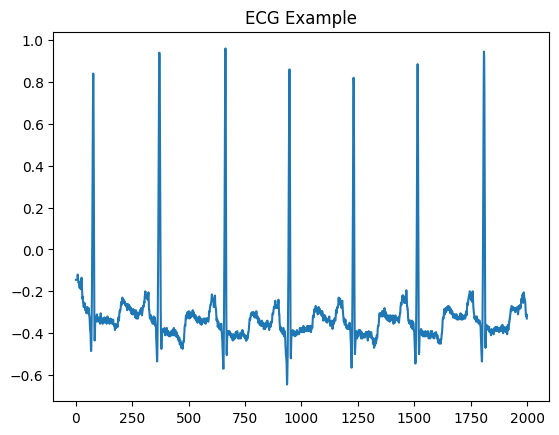

In [3]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord('100', pn_dir='mitdb')
ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')

signal = record.p_signal[:, 0]

plt.plot(signal[:2000])
plt.title("ECG Example")
plt.show()


In [4]:
import wfdb
import numpy as np

record_id = "100"
base_dir = "/Users/daeyeop/Desktop/EKG-Playground/data/mitbih"

rec_path = f"{base_dir}/{record_id}"

# 로컬 파일 읽기 (pn_dir 제거!)
record = wfdb.rdrecord(rec_path)
annotation = wfdb.rdann(rec_path, 'atr')

print(record.__dict__.keys())
print("Signals shape:", record.p_signal.shape)
print("Annotations:", len(annotation.sample))


dict_keys(['record_name', 'n_sig', 'fs', 'counter_freq', 'base_counter', 'sig_len', 'base_time', 'base_date', 'comments', 'sig_name', 'p_signal', 'd_signal', 'e_p_signal', 'e_d_signal', 'file_name', 'fmt', 'samps_per_frame', 'skew', 'byte_offset', 'adc_gain', 'baseline', 'units', 'adc_res', 'adc_zero', 'init_value', 'checksum', 'block_size'])
Signals shape: (650000, 2)
Annotations: 2274
